In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/06 18:29:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/06 18:29:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

all_evidence = session.spark.read.parquet(path_to_release_folder + "output/evidence")


efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet(path_to_intermediate_data_folder + "l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


g_p_s = session.spark.read.parquet(path_to_intermediate_data_folder + "genes_therapeutic_areas")
g_p_s.count()


26/02/06 18:29:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

In [4]:
l2g_full.show(1)


+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+--------------+-------------------+----+------+--------------------+----------+--------------+----+
|        studyLocusId|             studyId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|     variantId|            absBeta|year|is_nfe|          diseaseIds|nfe_common|non_nfe_common|rare|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+--------------+-------------------+----+------+--------------------+----------+--------------+----+
|8bb394926da96ce7e...|FINNGEN_R12_AB1_V...|ENSG00000128052|0.4011244773864746|         0|         0|  0|          1|0.15027322404371585|4_55014612_A_G|0.28786060190050455|2024|     0|[MONDO_0024294, E...|         0|             1|   0|
+--------------------+--------------------+-------------

# Load data


In [5]:
import pandas as pd

df_for_regression = pd.read_csv(path_to_intermediate_data_folder + "df_for_enrichment_regression.csv")


# Detecting non-linearity of TA


In [ ]:
import statsmodels.formula.api as smf


In [10]:
df = df_for_regression.copy()

model = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1)) + I(np.log(uniqueTherapeuticAreas+1) ** 2)", data=df
).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37373
Method:                           MLE   Df Model:                            3
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.01072
Time:                        18:38:55   Log-Likelihood:                -13722.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 3.587e-64
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -2.1295      0.023    -91.576      0.000      -2.175      -2.084
geneticSupport                     

In [ ]:
model2 = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1)) + I(np.log(uniqueTherapeuticAreas+1) ** 2)", data=df
).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport+I(np.log(uniqueTherapeuticAreas+1))", data=df).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=80.539, df=2, p=3.24e-18
model1 vs model0: LR=15.642, df=1, p=7.65e-05
model2 vs model1: LR=64.897, df=1, p=7.89e-16


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.utils import resample
from tqdm import tqdm

# 1. Исходная модель и параметры
formula = "outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1)) + I(np.log(uniqueTherapeuticAreas+1) ** 2)"
n_iterations = 1000  # Количество итераций (для статьи лучше 1000)
df = df_for_regression.copy()


# Функция для извлечения параметров модели
def get_model_params(model):
    # Коэффициенты
    params = model.params
    # P-values
    pvalues = model.pvalues
    # Точка перегиба (пик): x = -b / 2a
    # b = коэф. при логарифме, a = коэф. при квадрате логарифма
    b = params["I(np.log(uniqueTherapeuticAreas + 1))"]
    a = params["I(np.log(uniqueTherapeuticAreas + 1) ** 2)"]
    inflection_point = np.exp(-b / (2 * a)) - 1
    return params, pvalues, inflection_point


# Основная модель на полных данных
full_model = smf.logit(formula, data=df).fit(disp=False)
full_params, full_pvals, full_peak = get_model_params(full_model)

# Списки для хранения результатов
boot_results = []
significance_counts = {col: 0 for col in full_params.index}

print(f"Starting Robustness Check ({n_iterations} iterations)...")

for i in tqdm(range(n_iterations)):
    # --- BOOTSTRAP: Выборка с возвратом ---
    boot_df = resample(df, replace=True)

    # --- SUBSAMPLING: 80% данных без возврата ---
    # boot_df = df.sample(frac=0.8, replace=False) # Альтернативный вариант

    try:
        model = smf.logit(formula, data=boot_df).fit(disp=False)
        params, pvals, peak = get_model_params(model)

        # Сохраняем коэф. и пик
        res = params.to_dict()
        res["peak"] = peak
        boot_results.append(res)

        # Считаем, сколько раз коэф. был значим (p < 0.05)
        for col in significance_counts:
            if pvals[col] < 0.05:
                significance_counts[col] += 1
    except:
        continue

# 2. Обработка метрик
boot_results_df = pd.DataFrame(boot_results)

print("\n" + "=" * 50)
print("ROBUSTNESS METRICS REPORT")
print("=" * 50)

metrics = []
for col in full_params.index:
    col_data = boot_results_df[col]

    # Расчет 95% доверительного интервала (перцентильный бутстрап)
    ci_low = np.percentile(col_data, 2.5)
    ci_high = np.percentile(col_data, 97.5)

    # Устойчивость знака: доля итераций, где знак совпадает с исходным
    orig_sign = np.sign(full_params[col])
    sign_stability = (np.sign(col_data) == orig_sign).mean()

    # Доля значимых результатов
    sig_rate = significance_counts[col] / len(boot_results_df)

    metrics.append(
        {
            "Variable": col,
            "Original Coef": full_params[col],
            "Boot Mean": col_data.mean(),
            "Boot Std": col_data.std(),
            "95% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
            "Sign Stability": f"{sign_stability * 100:.1f}%",
            "P < 0.05 Rate": f"{sig_rate * 100:.1f}%",
        }
    )

# Добавляем метрику для точки перегиба (пика)
peak_data = boot_results_df["peak"]
metrics.append(
    {
        "Variable": "Peak (inflection point)",
        "Original Coef": full_peak,
        "Boot Mean": peak_data.mean(),
        "Boot Std": peak_data.std(),
        "95% CI": f"[{np.percentile(peak_data, 2.5):.2f}, {np.percentile(peak_data, 97.5):.2f}]",
        "Sign Stability": "N/A",
        "P < 0.05 Rate": "N/A",
    }
)

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

# Проверка основной гипотезы
is_robust = metrics_df.loc[metrics_df["Variable"].str.contains("squared|2"), "P < 0.05 Rate"].values[0]
print("\n" + "=" * 50)
print(f"CONCLUSION: Quadratic effect is significant in {is_robust} of cases.")
if float(is_robust.replace("%", "")) > 95:
    print("STATUS: HIGHLY ROBUST")
else:
    print("STATUS: CAUTION - Result might be sensitive to data composition.")


Starting Robustness Check (1000 iterations)...


100%|██████████| 1000/1000 [00:15<00:00, 65.47it/s]


ROBUSTNESS METRICS REPORT
                                  Variable  Original Coef  Boot Mean  Boot Std           95% CI Sign Stability P < 0.05 Rate
                                 Intercept      -2.129545  -2.129018  0.023264 [-2.175, -2.086]         100.0%        100.0%
                            geneticSupport       1.282613   1.273646  0.080456   [1.116, 1.428]         100.0%        100.0%
     I(np.log(uniqueTherapeuticAreas + 1))       0.568377   0.567702  0.063831   [0.441, 0.692]         100.0%        100.0%
I(np.log(uniqueTherapeuticAreas + 1) ** 2)      -0.266654  -0.266427  0.033582 [-0.332, -0.198]         100.0%        100.0%
                   Peak (inflection point)       1.903035   1.914410  0.148775     [1.66, 2.25]            N/A           N/A

CONCLUSION: Quadratic effect is significant in 100.0% of cases.
STATUS: HIGHLY ROBUST


# Detecting non-linearity of gPS


In [12]:
df = df_for_regression.copy()

model = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)", data=df
).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                37377
Model:                          Logit   Df Residuals:                    37373
Method:                           MLE   Df Model:                            3
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.01021
Time:                        18:40:11   Log-Likelihood:                -13729.
converged:                       True   LL-Null:                       -13871.
Covariance Type:            nonrobust   LLR p-value:                 4.153e-61
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.1193      0.023    -92.931      0.000      -2.164      -2.075
geneticSupport                         1.2671      0.085   

In [ ]:
model2 = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)", data=df
).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport+I(np.log(uniqueDiseases+1))", data=df).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=66.383, df=2, p=3.85e-15
model1 vs model0: LR=12.211, df=1, p=0.000475
model2 vs model1: LR=54.172, df=1, p=1.84e-13


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.utils import resample
from tqdm import tqdm

# 1. Исходная модель и параметры
formula = "outcome ~ geneticSupport + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)"
n_iterations = 1000  # Количество итераций (для статьи лучше 1000)
df = df_for_regression.copy()


# Функция для извлечения параметров модели
def get_model_params(model):
    # Коэффициенты
    params = model.params
    # P-values
    pvalues = model.pvalues
    # Точка перегиба (пик): x = -b / 2a
    # b = коэф. при логарифме, a = коэф. при квадрате логарифма
    b = params["I(np.log(uniqueDiseases + 1))"]
    a = params["I(np.log(uniqueDiseases + 1) ** 2)"]
    inflection_point = np.exp(-b / (2 * a)) - 1
    return params, pvalues, inflection_point


# Основная модель на полных данных
full_model = smf.logit(formula, data=df).fit(disp=False)
full_params, full_pvals, full_peak = get_model_params(full_model)

# Списки для хранения результатов
boot_results = []
significance_counts = {col: 0 for col in full_params.index}

print(f"Starting Robustness Check ({n_iterations} iterations)...")

for i in tqdm(range(n_iterations)):
    # --- BOOTSTRAP: Выборка с возвратом ---
    boot_df = resample(df, replace=True)

    # --- SUBSAMPLING: 80% данных без возврата ---
    # boot_df = df.sample(frac=0.8, replace=False) # Альтернативный вариант

    try:
        model = smf.logit(formula, data=boot_df).fit(disp=False)
        params, pvals, peak = get_model_params(model)

        # Сохраняем коэф. и пик
        res = params.to_dict()
        res["peak"] = peak
        boot_results.append(res)

        # Считаем, сколько раз коэф. был значим (p < 0.05)
        for col in significance_counts:
            if pvals[col] < 0.05:
                significance_counts[col] += 1
    except:
        continue

# 2. Обработка метрик
boot_results_df = pd.DataFrame(boot_results)

print("\n" + "=" * 50)
print("ROBUSTNESS METRICS REPORT")
print("=" * 50)

metrics = []
for col in full_params.index:
    col_data = boot_results_df[col]

    # Расчет 95% доверительного интервала (перцентильный бутстрап)
    ci_low = np.percentile(col_data, 2.5)
    ci_high = np.percentile(col_data, 97.5)

    # Устойчивость знака: доля итераций, где знак совпадает с исходным
    orig_sign = np.sign(full_params[col])
    sign_stability = (np.sign(col_data) == orig_sign).mean()

    # Доля значимых результатов
    sig_rate = significance_counts[col] / len(boot_results_df)

    metrics.append(
        {
            "Variable": col,
            "Original Coef": full_params[col],
            "Boot Mean": col_data.mean(),
            "Boot Std": col_data.std(),
            "95% CI": f"[{ci_low:.3f}, {ci_high:.3f}]",
            "Sign Stability": f"{sign_stability * 100:.1f}%",
            "P < 0.05 Rate": f"{sig_rate * 100:.1f}%",
        }
    )

# Добавляем метрику для точки перегиба (пика)
peak_data = boot_results_df["peak"]
metrics.append(
    {
        "Variable": "Peak (inflection point)",
        "Original Coef": full_peak,
        "Boot Mean": peak_data.mean(),
        "Boot Std": peak_data.std(),
        "95% CI": f"[{np.percentile(peak_data, 2.5):.2f}, {np.percentile(peak_data, 97.5):.2f}]",
        "Sign Stability": "N/A",
        "P < 0.05 Rate": "N/A",
    }
)

metrics_df = pd.DataFrame(metrics)
print(metrics_df.to_string(index=False))

# Проверка основной гипотезы
is_robust = metrics_df.loc[metrics_df["Variable"].str.contains("squared|2"), "P < 0.05 Rate"].values[0]
print("\n" + "=" * 50)
print(f"CONCLUSION: Quadratic effect is significant in {is_robust} of cases.")
if float(is_robust.replace("%", "")) > 95:
    print("STATUS: HIGHLY ROBUST")
else:
    print("STATUS: CAUTION - Result might be sensitive to data composition.")


Starting Robustness Check (1000 iterations)...


100%|██████████| 1000/1000 [00:15<00:00, 63.79it/s]


ROBUSTNESS METRICS REPORT
                          Variable  Original Coef  Boot Mean  Boot Std           95% CI Sign Stability P < 0.05 Rate
                         Intercept      -2.119259  -2.118848  0.023488 [-2.161, -2.071]         100.0%        100.0%
                    geneticSupport       1.267125   1.268385  0.086492   [1.098, 1.440]         100.0%        100.0%
     I(np.log(uniqueDiseases + 1))       0.371257   0.370363  0.047080   [0.271, 0.459]         100.0%        100.0%
I(np.log(uniqueDiseases + 1) ** 2)      -0.120032  -0.119885  0.016928 [-0.152, -0.085]         100.0%        100.0%
           Peak (inflection point)       3.694997   3.727206  0.395309     [3.07, 4.55]            N/A           N/A

CONCLUSION: Quadratic effect is significant in 100.0% of cases.
STATUS: HIGHLY ROBUST


# Making plots


Running bootstrap (B=200)...


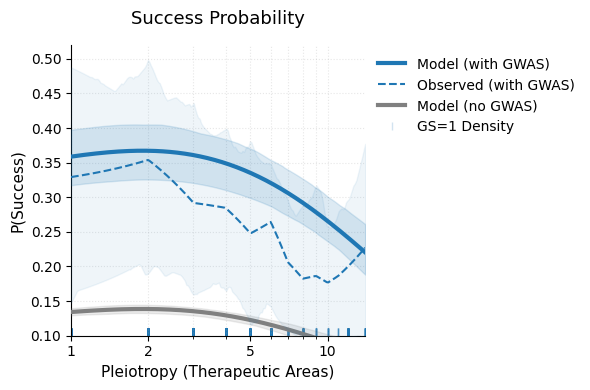

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d

# 1. Подготовка данных и базовой модели
df_full = df_for_regression.copy()
# Замена переменной в формуле
formula = "outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1)) + I(np.log(uniqueTherapeuticAreas+1) ** 2)"
base_model = smf.logit(formula, data=df_full).fit(disp=False)

# Сетка для предсказаний
x_min, x_max = df_full[df_full["uniqueTherapeuticAreas"] >= 1]["uniqueTherapeuticAreas"].agg(["min", "max"])
x_grid = np.geomspace(x_min, x_max, 200)

pred_df_gs1 = pd.DataFrame({"geneticSupport": 1, "uniqueTherapeuticAreas": x_grid})
pred_df_gs0 = pd.DataFrame({"geneticSupport": 0, "uniqueTherapeuticAreas": x_grid})

# 2. Бутстрап (Модели для обеих групп + Lowess только для GS=1)
B = 200
rng = np.random.default_rng(42)

res = {"logit_gs1": [], "logit_gs0": [], "lowess_gs1": []}

print(f"Running bootstrap (B={B})...")
for i in range(B):
    boot_idx = rng.integers(0, len(df_full), len(df_full))
    df_boot = df_full.iloc[boot_idx]

    # А. Логит (Parametric)
    try:
        m = smf.logit(formula, data=df_boot).fit(disp=False)
        res["logit_gs1"].append(m.predict(pred_df_gs1).values)
        res["logit_gs0"].append(m.predict(pred_df_gs0).values)
    except:
        continue

    # Б. Lowess (Empirical) только для GS=1
    sub = df_boot[(df_boot["geneticSupport"] == 1) & (df_boot["uniqueTherapeuticAreas"] >= 1)]
    if sub["uniqueTherapeuticAreas"].nunique() > 3:
        try:
            lw = sm.nonparametric.lowess(sub["outcome"], sub["uniqueTherapeuticAreas"], frac=0.3)
            _, u_idx = np.unique(lw[:, 0], return_index=True)
            f_interp = interp1d(lw[u_idx, 0], lw[u_idx, 1], bounds_error=False, fill_value="extrapolate")
            p = f_interp(x_grid)
            if not np.isnan(p).any():
                res["lowess_gs1"].append(p)
        except:
            continue


def get_ci(data):
    arr = np.array(data)
    return np.nanmean(arr, axis=0), np.nanpercentile(arr, [2.5, 97.5], axis=0)


l_m1, l_ci1 = get_ci(res["logit_gs1"])
l_m0, l_ci0 = get_ci(res["logit_gs0"])
w_m1, w_ci1 = get_ci(res["lowess_gs1"])

# 3. Визуализация
fig, ax = plt.subplots(figsize=(6, 4))

# --- Модель GS=1 (Синий) ---
ax.plot(x_grid, base_model.predict(pred_df_gs1), color="#1f77b4", lw=3, label="Model (with GWAS)", zorder=10)
ax.fill_between(x_grid, l_ci1[0], l_ci1[1], color="#1f77b4", alpha=0.15, zorder=9)

# --- Lowess GS=1 (Пунктир) ---
ax.plot(x_grid, w_m1, color="#1f77b4", lw=1.5, ls="--", label="Observed (with GWAS)", zorder=8)
ax.fill_between(x_grid, w_ci1[0], w_ci1[1], color="#1f77b4", alpha=0.07, zorder=7)

# --- Модель GS=0 (Серый) ---
ax.plot(x_grid, base_model.predict(pred_df_gs0), color="gray", lw=3, label="Model (no GWAS)", zorder=6)
ax.fill_between(x_grid, l_ci0[0], l_ci0[1], color="gray", alpha=0.15, zorder=5)

# Rug plot (плотность данных)
ax.plot(
    df_full[df_full["geneticSupport"] == 1]["uniqueTherapeuticAreas"],
    np.full(len(df_full[df_full["geneticSupport"] == 1]), 0.105),
    "|",
    color="#1f77b4",
    alpha=0.2,
    label="GS=1 Density",
    zorder=1,
)

# Оформление
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 2, 5, 10, 20])  # Подкорректировал тики под типичное кол-во областей
ax.set_xlim(x_min, x_max)
ax.set_ylim(bottom=0.1)

ax.set_xlabel("Pleiotropy (Therapeutic Areas)", fontsize=11)
ax.set_ylabel("P(Success)", fontsize=11)
ax.set_title("Success Probability", fontsize=13, pad=15)
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


Running bootstrap (B=200)...


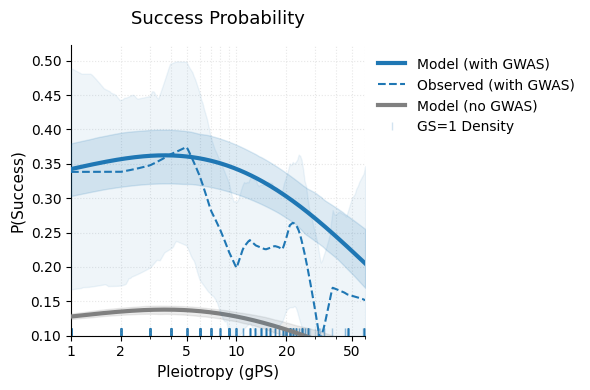

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d

# 1. Подготовка данных и базовой модели
df_full = df_for_regression.copy()
formula = "outcome ~ geneticSupport + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)"
base_model = smf.logit(formula, data=df_full).fit(disp=False)

# Сетка для предсказаний
x_min, x_max = df_full[df_full["uniqueDiseases"] >= 1]["uniqueDiseases"].agg(["min", "max"])
x_grid = np.geomspace(x_min, x_max, 200)

pred_df_gs1 = pd.DataFrame({"geneticSupport": 1, "uniqueDiseases": x_grid})
pred_df_gs0 = pd.DataFrame({"geneticSupport": 0, "uniqueDiseases": x_grid})

# 2. Бутстрап (Модели для обеих групп + Lowess только для GS=1)
B = 200
rng = np.random.default_rng(42)

res = {"logit_gs1": [], "logit_gs0": [], "lowess_gs1": []}

print(f"Running bootstrap (B={B})...")
for i in range(B):
    boot_idx = rng.integers(0, len(df_full), len(df_full))
    df_boot = df_full.iloc[boot_idx]

    # А. Логит (Parametric)
    try:
        m = smf.logit(formula, data=df_boot).fit(disp=False)
        res["logit_gs1"].append(m.predict(pred_df_gs1).values)
        res["logit_gs0"].append(m.predict(pred_df_gs0).values)
    except:
        continue

    # Б. Lowess (Empirical) только для GS=1
    sub = df_boot[(df_boot["geneticSupport"] == 1) & (df_boot["uniqueDiseases"] >= 1)]
    if sub["uniqueDiseases"].nunique() > 3:
        try:
            lw = sm.nonparametric.lowess(sub["outcome"], sub["uniqueDiseases"], frac=0.3)
            _, u_idx = np.unique(lw[:, 0], return_index=True)
            f_interp = interp1d(lw[u_idx, 0], lw[u_idx, 1], bounds_error=False, fill_value="extrapolate")
            p = f_interp(x_grid)
            if not np.isnan(p).any():
                res["lowess_gs1"].append(p)
        except:
            continue


def get_ci(data):
    arr = np.array(data)
    return np.nanmean(arr, axis=0), np.nanpercentile(arr, [2.5, 97.5], axis=0)


l_m1, l_ci1 = get_ci(res["logit_gs1"])
l_m0, l_ci0 = get_ci(res["logit_gs0"])
w_m1, w_ci1 = get_ci(res["lowess_gs1"])

# 3. Визуализация
fig, ax = plt.subplots(figsize=(6, 4))

# --- Модель GS=1 (Синий) ---
ax.plot(x_grid, base_model.predict(pred_df_gs1), color="#1f77b4", lw=3, label="Model (with GWAS)", zorder=10)
ax.fill_between(x_grid, l_ci1[0], l_ci1[1], color="#1f77b4", alpha=0.15, zorder=9)

# --- Lowess GS=1 (Пунктир) ---
ax.plot(x_grid, w_m1, color="#1f77b4", lw=1.5, ls="--", label="Observed (with GWAS)", zorder=8)
ax.fill_between(x_grid, w_ci1[0], w_ci1[1], color="#1f77b4", alpha=0.07, zorder=7)

# --- Модель GS=0 (Серый) ---
ax.plot(x_grid, base_model.predict(pred_df_gs0), color="gray", lw=3, label="Model (no GWAS)", zorder=6)
ax.fill_between(x_grid, l_ci0[0], l_ci0[1], color="gray", alpha=0.15, zorder=5)

# Rug plot (плотность данных)
ax.plot(
    df_full[df_full["geneticSupport"] == 1]["uniqueDiseases"],
    np.full(len(df_full[df_full["geneticSupport"] == 1]), 0.105),
    "|",
    color="#1f77b4",
    alpha=0.2,
    label="GS=1 Density",
    zorder=1,
)

# Оформление
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([1, 2, 5, 10, 20, 50])
ax.set_xlim(x_min, x_max)
ax.set_ylim(bottom=0.1)

ax.set_xlabel("Pleiotropy (gPS)", fontsize=11)
ax.set_ylabel("P(Success)", fontsize=11)
ax.set_title("Success Probability", fontsize=13, pad=15)
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


# Replication on Minikel et al dataset


In [ ]:
phrm_df = session.spark.read.parquet(path_to_intermediate_data_folder + "minikel_etal_data_processed.parquet")
phrm_df_expl = (
    phrm_df.withColumn("targetId", f.explode(f.col("targetIds")))
    .withColumn("diseaseId", f.explode(f.col("diseaseIds")))
    .select("diseaseId", "maxClinicalPhase", "targetId")
    .withColumnRenamed("maxClinicalPhase", "ClinicalPhase")
    .withColumnRenamed("targetId", "geneId")
    .filter(f.col("geneId").isNotNull())
    .filter(f.col("diseaseId").isNotNull())
    .distinct()
)
phrm_df_expl.count()


29222

In [18]:
phrm_df_expl_2 = phrm_df_expl.groupBy("diseaseId", "geneId").agg(
    # 1. Get the highest clinical phase
    f.max("ClinicalPhase").alias("maxClinicalPhase")
)
phrm_df_expl_2.count()


29181

In [ ]:
phrm_df_expl_2 = phrm_df_expl_2.join(
    g_p_s.select("geneId", "uniqueDiseases", "uniqueTherapeuticAreas"), "geneId", "left"
).fillna({"uniqueDiseases": 0, "uniqueTherapeuticAreas": "0"})

phrm_df_expl_2.count()


29181

In [ ]:
full_l2g_evidnce = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)
evid_indirect = chemblDrugEnrichment.evidence_to_indirect_assosiations(
    full_l2g_evidnce,
    disease_index_orig,
    use_max=True,
    efo_to_remove=efo_to_remove,
).cache()
evid_indirect.count()


151704

In [22]:
evid_indirect = (
    evid_indirect.select("targetId", "diseaseId")
    .withColumnRenamed("targetId", "geneId")
    .withColumn("geneticSupport", f.lit(1))
)


In [23]:
phrm_df_expl_2 = (
    phrm_df_expl_2.join(evid_indirect, ["geneId", "diseaseId"], "left").fillna({"geneticSupport": 0}).cache()
)
phrm_df_expl_2.count()


29181

In [ ]:
phrm_df_expl_2 = phrm_df_expl_2.filter(~f.col("diseaseId").isin(efo_to_remove))
phrm_df_expl_2.count()


16746

In [25]:
df = phrm_df_expl_2.toPandas()

df["outcome"] = df["maxClinicalPhase"].apply(lambda x: int(x) == 4).astype(int)
df_support = df[df["uniqueDiseases"] > 0]


In [ ]:
df_for_regression = df[df["maxClinicalPhase"] > 0]


In [ ]:
model2 = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)", data=df_for_regression
).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport + I(np.log(uniqueDiseases+1))", data=df_for_regression).fit(disp=False)
model0 = smf.logit("outcome ~ geneticSupport", data=df_for_regression).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=9.011, df=2, p=0.011
model1 vs model0: LR=7.997, df=1, p=0.00468
model2 vs model1: LR=1.014, df=1, p=0.314


In [ ]:
model2 = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1)) + I(np.log(uniqueTherapeuticAreas+1) ** 2)",
    data=df_for_regression,
).fit(disp=False)
model1 = smf.logit("outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1))", data=df_for_regression).fit(
    disp=False
)
model0 = smf.logit("outcome ~ geneticSupport", data=df_for_regression).fit(disp=False)
from scipy.stats import chi2


def lr_test(model_full, model_restricted):
    """Likelihood-ratio test for nested models.
    Returns (LR_stat, pvalue, df_diff).
    """
    llf_full = float(model_full.llf)
    llf_red = float(model_restricted.llf)
    k_full = len(model_full.params)
    k_red = len(model_restricted.params)
    df_diff = k_full - k_red
    if df_diff <= 0:
        raise ValueError("models are not nested in the expected direction (full must have more params)")
    LR = 2.0 * (llf_full - llf_red)
    pval = chi2.sf(LR, df_diff)
    return LR, pval, df_diff


# compare models
LR20, p20, df20 = lr_test(model2, model0)  # model2 vs model0
LR10, p10, df10 = lr_test(model1, model0)  # model1 vs model0
LR21, p21, df21 = lr_test(model2, model1)  # model2 vs model1

print(f"model2 vs model0: LR={LR20:.3f}, df={df20}, p={p20:.3g}")
print(f"model1 vs model0: LR={LR10:.3f}, df={df10}, p={p10:.3g}")
print(f"model2 vs model1: LR={LR21:.3f}, df={df21}, p={p21:.3g}")
# ...existing code...


model2 vs model0: LR=8.935, df=2, p=0.0115
model1 vs model0: LR=4.804, df=1, p=0.0284
model2 vs model1: LR=4.131, df=1, p=0.0421


In [33]:
model = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueDiseases+1)) + I(np.log(uniqueDiseases+1) ** 2)", data=df_for_regression
).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                10565
Model:                          Logit   Df Residuals:                    10561
Method:                           MLE   Df Model:                            3
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                0.001378
Time:                        19:23:08   Log-Likelihood:                -5767.0
converged:                       True   LL-Null:                       -5774.9
Covariance Type:            nonrobust   LLR p-value:                  0.001182
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.2713      0.038    -33.855      0.000      -1.345      -1.198
geneticSupport                         0.1736      0.099   

In [ ]:
model = smf.logit(
    "outcome ~ geneticSupport + I(np.log(uniqueTherapeuticAreas+1)) + I(np.log(uniqueTherapeuticAreas+1) ** 2)",
    data=df_for_regression,
).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                10565
Model:                          Logit   Df Residuals:                    10561
Method:                           MLE   Df Model:                            3
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                0.001371
Time:                        19:23:08   Log-Likelihood:                -5767.0
converged:                       True   LL-Null:                       -5774.9
Covariance Type:            nonrobust   LLR p-value:                  0.001226
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -1.2766      0.038    -33.192      0.000      -1.352      -1.201
geneticSupport                     